In [1]:
!pip install numpy pandas matplotlib scikit-learn tensorflow

In [2]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score    #about all the library 

In [3]:
# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [4]:
# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]


In [5]:
# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [22]:
# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
print(X_train[:5, :])
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(" ------------- ")
print(scaler.fit_transform(X_train[:5, :]))


[[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
  -1.3728112   1.27258656]
 [-0.03584338  1.61811813 -0.40283542 -0.12853018 -0.09890135 -0.11736222
  -0.87669601  0.70916212]
 [ 0.14470145 -1.95271028  0.08821601 -0.25753771 -0.44981806 -0.03227969
  -0.46014647 -0.44760309]
 [-1.01786438  0.58654547 -0.60001532 -0.14515634 -0.00743434  0.07750687
  -1.38217186  1.23269811]
 [-0.17148831  1.14200767  0.3490073   0.08662432 -0.48587717 -0.06883176
   0.5320839  -0.10855122]]
 ------------- 
[[-0.11226211  0.         -0.07920337 -0.65935678  1.81908585  0.95012442
  -0.93012849  1.06047025]
 [ 0.61437942  1.03022321 -0.75259056  0.01748922 -0.09758293 -1.36352252
  -0.23187339  0.25405613]
 [ 1.06621402 -1.86727957  0.69822223 -1.07624099 -0.87319231 -0.19691761
   0.3543974  -1.40159056]
 [-1.84324338  0.19316685 -1.3351591  -0.12346789  0.10458091  1.30841524
  -0.94330312  1.00337899]
 [ 0.27491205  0.64388951  1.4687308   1.84157644 -0.95289152 -0.69809953


In [7]:
# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression       /// why this 
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 1.4076 - mae: 0.8204 - val_loss: 0.4183 - val_mae: 0.4473
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3759 - mae: 0.4333 - val_loss: 0.3756 - val_mae: 0.4258
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3483 - mae: 0.4185 - val_loss: 0.3781 - val_mae: 0.4371
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3238 - mae: 0.3988 - val_loss: 0.3425 - val_mae: 0.4125
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3007 - mae: 0.3873 - val_loss: 0.3353 - val_mae: 0.3971
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3011 - mae: 0.3799 - val_loss: 0.3239 - val_mae: 0.3987
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2986 - mae: 0.3756 - val_loss: 0.3306 - val_mae: 0.3834
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2966 - mae: 0.3769 - val_loss: 0.3199 - val_mae: 0.3805
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [9]:
# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)    #traning vs testing acuueary curve

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2828 - mae: 0.3442
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Test MAE: 0.34478235244750977
RMSE: 0.5319759751927059
R2 Score: 0.7840380805676949


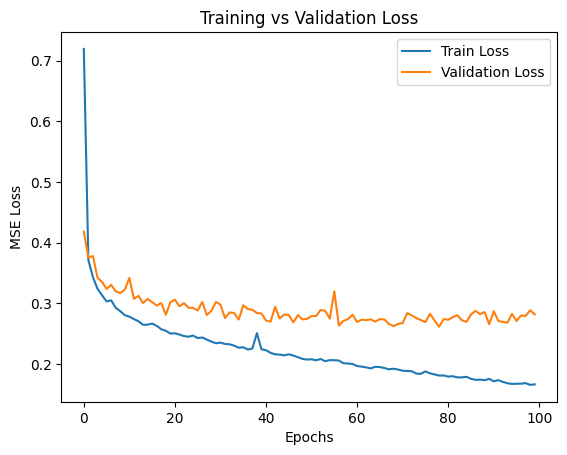

In [10]:
# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()


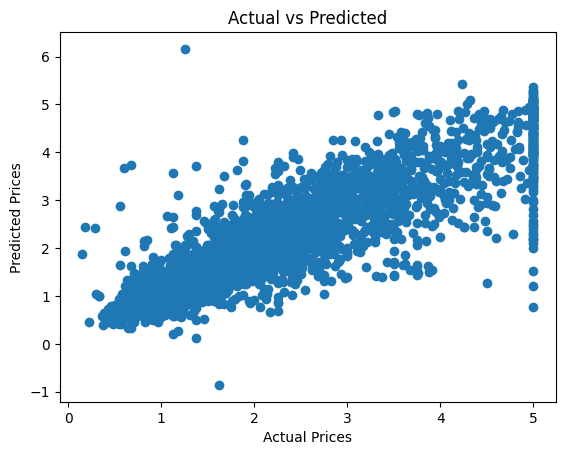

In [11]:
# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [12]:
# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    verbose=1
)

Epoch 1/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1567 - mae: 0.2742 - val_loss: 0.2732 - val_mae: 0.3396
Epoch 2/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1511 - mae: 0.2690 - val_loss: 0.2737 - val_mae: 0.3417
Epoch 3/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1437 - mae: 0.2638 - val_loss: 0.2703 - val_mae: 0.3405
Epoch 4/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1459 - mae: 0.2628 - val_loss: 0.2701 - val_mae: 0.3378
Epoch 5/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1472 - mae: 0.2626 - val_loss: 0.2717 - val_mae: 0.3359
Epoch 6/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1507 - mae: 0.2658 - val_loss: 0.2726 - val_mae: 0.3403
Epoch 7/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1481 - mae: 0.2676 - val_loss: 0.2854 - val_mae: 0.3408
Epoch 8/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1485 - mae: 0.2681 - val_loss: 0.2754 - val_mae: 0.3410
Epoch 9/100
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

In [13]:
# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)    #traning vs testing acuueary curve

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2973 - mae: 0.3461
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Test MAE: 0.34319472312927246
RMSE: 0.5412277912945563
R2 Score: 0.7764609927636398


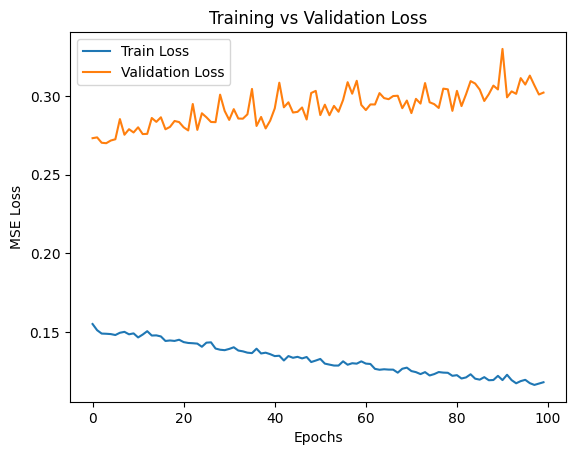

In [14]:
# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()


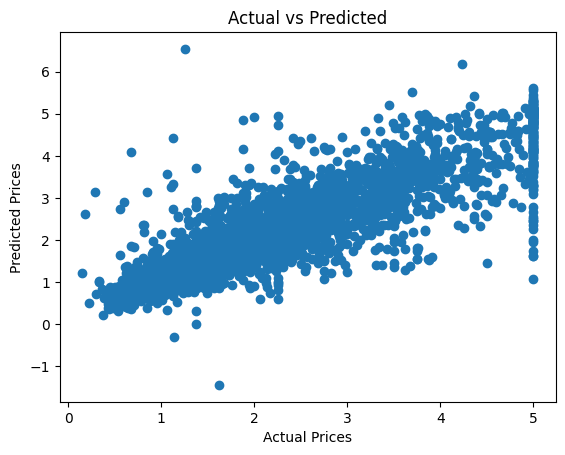

In [16]:
# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [26]:
# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=1024,
    verbose=1
)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0916 - mae: 0.2119 - val_loss: 0.3061 - val_mae: 0.3496
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0901 - mae: 0.2104 - val_loss: 0.3064 - val_mae: 0.3509
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0919 - mae: 0.2123 - val_loss: 0.3063 - val_mae: 0.3494
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0891 - mae: 0.2098 - val_loss: 0.3072 - val_mae: 0.3529
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0890 - mae: 0.2106 - val_loss: 0.3083 - val_mae: 0.3514
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0911 - mae: 0.2115 - val_loss: 0.3076 - val_mae: 0.3507
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0910 - mae: 0.2110 - val_loss: 0.3064 - val_mae: 0.3515
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0893 - mae: 0.2099 - val_loss: 0.3077 - val_mae: 0.3516
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.08

In [24]:
# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)    #traning vs testing acuueary curve

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2922 - mae: 0.3440
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Test MAE: 0.3417228162288666
RMSE: 0.540310542631926
R2 Score: 0.777218038546178


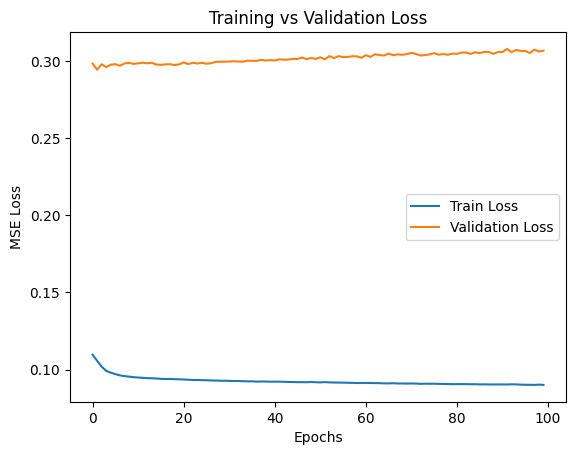

In [25]:
# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()